In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [140]:
df_tracks = pd.read_csv(r"C:\Users\kinga\Desktop\studia\DS\ED_project\tracks.csv", index_col=0, header=[0, 1])
df_tracks.head()


album                                                     \
         comments         date_created        date_released engineer   
track_id                                                               
2               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
3               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
5               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
10              0  2008-11-26 01:45:08  2008-02-06 00:00:00      NaN   
20              0  2008-11-26 01:45:05  2009-01-06 00:00:00      NaN   

                                                                          \
         favorites id                                information listens   
track_id                                                                   
2                4  1                                    <p></p>    6073   
3                4  1                                    <p></p>    6073   
5                4  1                                    <p></p>    6073   
10               4  6                                        NaN   47632   
20               2  4  <p> "spiritual songs" from Nicky Cook</p>    2710   

                        ...       track                         \
         producer tags  ... information interest language_code   
track_id                ...                                      
2             NaN   []  ...         NaN     4656            en   
3             NaN   []  ...         NaN     1470            en   
5             NaN   []  ...         NaN     1933            en   
10            NaN   []  ...         NaN    54881            en   
20            NaN   []  ...         NaN      978            en   

                                                                              \
                                                    license listens lyricist   
track_id                                                                       
2         Attribution-NonCommercial-ShareAlike 3.0 Inter...    1293      NaN   
3         Attribution-NonCommercial-ShareAlike 3.0 Inter...     514      NaN   
5         Attribution-NonCommercial-ShareAlike 3.0 Inter...    1151      NaN   
10        Attribution-NonCommercial-NoDerivatives (aka M...   50135      NaN   
20        Attribution-NonCommercial-NoDerivatives (aka M...     361      NaN   

                                                 
         number publisher tags            title  
track_id                                         
2             3       NaN   []             Food  
3             4       NaN   []     Electric Ave  
5             6       NaN   []       This World  
10            1       NaN   []          Freeway  
20            3       NaN   []  Spiritual Level  

[5 rows x 52 columns]

In [141]:
keep_tracks = df_tracks[df_tracks[('set', 'subset')] == 'small']
df_tracks = keep_tracks[[('track', 'genre_top'), ('set', 'split')]].reset_index()
df_tracks.columns = ['track_id', 'genre_top', 'split']

In [142]:
df_tracks.head()

,track_id,genre_top,split
0,2,Hip-Hop,training
1,5,Hip-Hop,training
2,10,Pop,training
3,140,Folk,training
4,141,Folk,training


In [143]:
df_tracks.value_counts('split')

split
training      6400
test           800
validation     800
Name: count, dtype: int64

In [144]:
df_tracks.shape

(8000, 3)

In [145]:
df_tracks["genre_top"].value_counts()

genre_top
Hip-Hop          1000
Pop              1000
Folk             1000
Experimental     1000
Rock             1000
International    1000
Electronic       1000
Instrumental     1000
Name: count, dtype: int64

In [146]:
df = pd.read_csv(r"C:\Users\kinga\Desktop\studia\DS\ED_project\features_small_mniej_cech.csv")
df.head()

,track_id,chroma_stft_mean_01,chroma_stft_mean_02,chroma_stft_mean_03,chroma_stft_mean_04,chroma_stft_mean_05,chroma_stft_mean_06,chroma_stft_mean_07,chroma_stft_mean_08,chroma_stft_mean_09,...,mfcc_std_17,mfcc_std_18,mfcc_std_19,mfcc_std_20,rms_mean_01,rms_std_01,spectral_centroid_mean_01,spectral_centroid_std_01,zcr_mean_01,zcr_std_01
0,2,0.747006,0.465571,0.376991,0.346401,0.276217,0.234040,0.272904,0.419901,0.372483,...,7.308831,7.230115,7.195039,6.366723,0.085953,0.053469,3056.587891,997.470154,0.164406,0.093938
1,5,0.408774,0.578310,0.398189,0.341066,0.322690,0.329029,0.373279,0.398300,0.488417,...,6.713108,6.629267,8.085360,8.035872,0.088805,0.053615,2430.188965,878.139465,0.100544,0.067248
2,10,0.283685,0.649419,0.330624,0.347292,0.231403,0.323438,0.700743,0.338985,0.381055,...,5.731712,6.350440,5.508020,5.445374,0.114076,0.031983,2358.129150,382.231567,0.148947,0.028327
3,140,0.242838,0.270964,0.364772,0.345893,0.379862,0.433202,0.273431,0.234015,0.200707,...,6.154853,6.254518,6.819814,6.646987,0.041877,0.024219,1765.877808,1036.000610,0.044525,0.052389
4,141,0.164104,0.153202,0.243002,0.186743,0.234106,0.373787,0.242960,0.225383,0.214111,...,9.598771,7.808608,8.252582,9.453534,0.061718,0.048319,1666.702881,809.798645,0.062031,0.052299


In [147]:
df = df.merge(df_tracks[['track_id', 'genre_top', 'split']], on='track_id', how='left')

In [148]:
df.head()

,track_id,chroma_stft_mean_01,chroma_stft_mean_02,chroma_stft_mean_03,chroma_stft_mean_04,chroma_stft_mean_05,chroma_stft_mean_06,chroma_stft_mean_07,chroma_stft_mean_08,chroma_stft_mean_09,...,mfcc_std_19,mfcc_std_20,rms_mean_01,rms_std_01,spectral_centroid_mean_01,spectral_centroid_std_01,zcr_mean_01,zcr_std_01,genre_top,split
0,2,0.747006,0.465571,0.376991,0.346401,0.276217,0.234040,0.272904,0.419901,0.372483,...,7.195039,6.366723,0.085953,0.053469,3056.587891,997.470154,0.164406,0.093938,Hip-Hop,training
1,5,0.408774,0.578310,0.398189,0.341066,0.322690,0.329029,0.373279,0.398300,0.488417,...,8.085360,8.035872,0.088805,0.053615,2430.188965,878.139465,0.100544,0.067248,Hip-Hop,training
2,10,0.283685,0.649419,0.330624,0.347292,0.231403,0.323438,0.700743,0.338985,0.381055,...,5.508020,5.445374,0.114076,0.031983,2358.129150,382.231567,0.148947,0.028327,Pop,training
3,140,0.242838,0.270964,0.364772,0.345893,0.379862,0.433202,0.273431,0.234015,0.200707,...,6.819814,6.646987,0.041877,0.024219,1765.877808,1036.000610,0.044525,0.052389,Folk,training
4,141,0.164104,0.153202,0.243002,0.186743,0.234106,0.373787,0.242960,0.225383,0.214111,...,8.252582,9.453534,0.061718,0.048319,1666.702881,809.798645,0.062031,0.052299,Folk,training


In [149]:
col = df.pop('genre_top')
df.insert(1, 'genre', col)

df.head()

,track_id,genre,chroma_stft_mean_01,chroma_stft_mean_02,chroma_stft_mean_03,chroma_stft_mean_04,chroma_stft_mean_05,chroma_stft_mean_06,chroma_stft_mean_07,chroma_stft_mean_08,...,mfcc_std_18,mfcc_std_19,mfcc_std_20,rms_mean_01,rms_std_01,spectral_centroid_mean_01,spectral_centroid_std_01,zcr_mean_01,zcr_std_01,split
0,2,Hip-Hop,0.747006,0.465571,0.376991,0.346401,0.276217,0.234040,0.272904,0.419901,...,7.230115,7.195039,6.366723,0.085953,0.053469,3056.587891,997.470154,0.164406,0.093938,training
1,5,Hip-Hop,0.408774,0.578310,0.398189,0.341066,0.322690,0.329029,0.373279,0.398300,...,6.629267,8.085360,8.035872,0.088805,0.053615,2430.188965,878.139465,0.100544,0.067248,training
2,10,Pop,0.283685,0.649419,0.330624,0.347292,0.231403,0.323438,0.700743,0.338985,...,6.350440,5.508020,5.445374,0.114076,0.031983,2358.129150,382.231567,0.148947,0.028327,training
3,140,Folk,0.242838,0.270964,0.364772,0.345893,0.379862,0.433202,0.273431,0.234015,...,6.254518,6.819814,6.646987,0.041877,0.024219,1765.877808,1036.000610,0.044525,0.052389,training
4,141,Folk,0.164104,0.153202,0.243002,0.186743,0.234106,0.373787,0.242960,0.225383,...,7.808608,8.252582,9.453534,0.061718,0.048319,1666.702881,809.798645,0.062031,0.052299,training


# statystyka

In [150]:
miss = df.isnull().sum()

In [151]:
miss.sort_values()

track_id                      0
genre                         0
split                         0
zcr_mean_01                   6
zcr_std_01                    6
                             ..
rms_std_01                   10
rms_mean_01                  10
spectral_centroid_std_01     10
mfcc_std_20                  10
spectral_centroid_mean_01    10
Length: 73, dtype: int64

In [154]:
# handling missing values - mean in class (genre id)
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(
    df.groupby('genre')[numeric_cols].transform('mean')
)

In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 73 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   track_id                   8000 non-null   int64  
 1   genre                      8000 non-null   object 
 2   chroma_stft_mean_01        8000 non-null   float64
 3   chroma_stft_mean_02        8000 non-null   float64
 4   chroma_stft_mean_03        8000 non-null   float64
 5   chroma_stft_mean_04        8000 non-null   float64
 6   chroma_stft_mean_05        8000 non-null   float64
 7   chroma_stft_mean_06        8000 non-null   float64
 8   chroma_stft_mean_07        8000 non-null   float64
 9   chroma_stft_mean_08        8000 non-null   float64
 10  chroma_stft_mean_09        8000 non-null   float64
 11  chroma_stft_mean_10        8000 non-null   float64
 12  chroma_stft_mean_11        8000 non-null   float64
 13  chroma_stft_mean_12        8000 non-null   float

In [156]:
df.describe()

,track_id,chroma_stft_mean_01,chroma_stft_mean_02,chroma_stft_mean_03,chroma_stft_mean_04,chroma_stft_mean_05,chroma_stft_mean_06,chroma_stft_mean_07,chroma_stft_mean_08,chroma_stft_mean_09,...,mfcc_std_17,mfcc_std_18,mfcc_std_19,mfcc_std_20,rms_mean_01,rms_std_01,spectral_centroid_mean_01,spectral_centroid_std_01,zcr_mean_01,zcr_std_01
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,...,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,84126.770125,0.384153,0.358588,0.389807,0.362426,0.390536,0.365014,0.363271,0.393923,0.372966,...,7.123442,7.184168,7.304115,7.425555,0.109186,0.038522,1900.345000,618.298764,0.084189,0.041452
std,43297.426287,0.152839,0.139345,0.149271,0.141920,0.151528,0.147427,0.142069,0.149294,0.145997,...,2.057759,2.097927,2.226888,2.380265,0.059035,0.020522,710.045044,312.447756,0.044135,0.025614
min,2.000000,0.000086,0.000028,0.000160,0.013705,0.000107,0.002560,0.006492,0.003290,0.001849,...,1.986344,1.603659,2.280345,2.260303,0.000005,0.000000,194.182846,19.656221,0.000000,0.000000
25%,49063.500000,0.273948,0.258644,0.284567,0.259755,0.282736,0.259966,0.263401,0.289450,0.268044,...,5.715921,5.777391,5.791659,5.803681,0.064954,0.023269,1392.002197,383.831131,0.053732,0.023435
50%,89281.000000,0.375412,0.349119,0.383240,0.353619,0.385797,0.357011,0.356580,0.390202,0.364646,...,6.833184,6.863219,6.973696,7.017993,0.102611,0.034711,1884.867248,582.305450,0.076833,0.035815
75%,122545.000000,0.482452,0.446623,0.481659,0.451587,0.488489,0.458809,0.453405,0.490336,0.466023,...,8.102801,8.193905,8.340853,8.542696,0.145489,0.049832,2368.226623,812.604615,0.105589,0.053379
max,155066.000000,1.000000,0.992950,0.996802,0.989316,0.975264,0.999956,0.974532,1.000000,0.997444,...,22.927616,20.595741,21.905958,28.510353,0.534026,0.169386,6765.746582,2237.504639,0.626993,0.215885


# eda

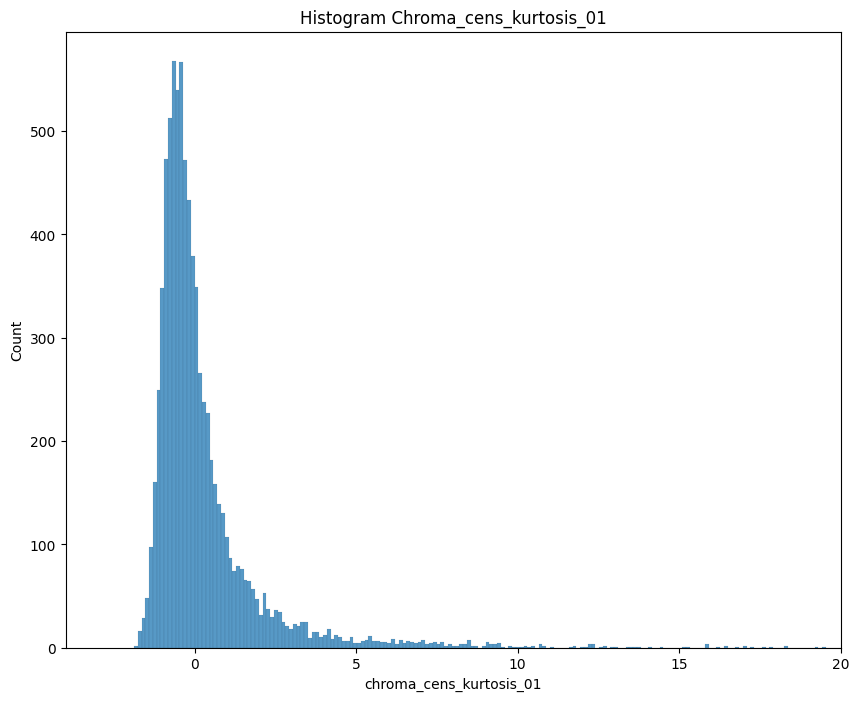

In [16]:
# histogram chroma_cens_kurtosis_01
plt.figure(figsize=(10, 8))
sns.histplot(df['chroma_cens_kurtosis_01'])
plt.title('Histogram Chroma_cens_kurtosis_01')
plt.xlim(-4, 20)
plt.show()

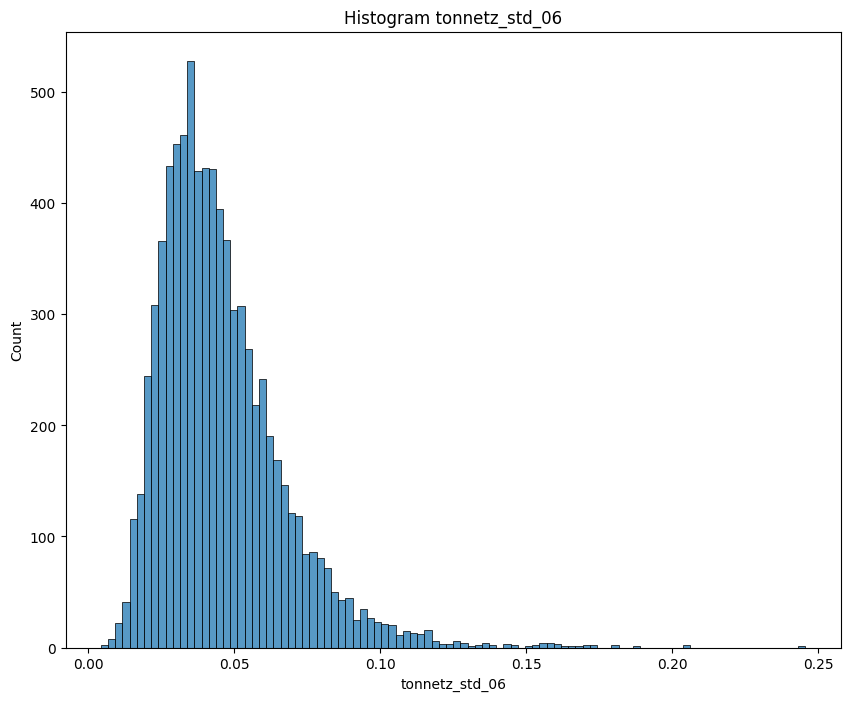

In [17]:
# histogram tonnetz_std_06
plt.figure(figsize=(10, 8))
sns.histplot(df['tonnetz_std_06'])
plt.title('Histogram tonnetz_std_06')
plt.show()

## PCA

In [157]:
from sklearn.decomposition import PCA

In [159]:
train_mask = df['split'] == 'training'
test_mask = df['split'].isin(['test', 'validation'])

# Przygotowanie X (usuwamy kolumny opisowe)
# Upewnij się, że nazwy kolumn do usunięcia zgadzają się z Twoim df
cols_to_drop = ['track_id', 'genre', 'split']

X_train = df.loc[train_mask].drop(columns=cols_to_drop)
y_train = df.loc[train_mask, 'genre']

X_test = df.loc[test_mask].drop(columns=cols_to_drop)
y_test = df.loc[test_mask, 'genre']

# Sprawdzenie wymiarów
print(f"Trening: {X_train.shape[0]} utworów")
print(f"Test (+Val): {X_test.shape[0]} utworów")

Trening: 6400 utworów
Test (+Val): 1600 utworów


In [160]:
X_test.head()

,chroma_stft_mean_01,chroma_stft_mean_02,chroma_stft_mean_03,chroma_stft_mean_04,chroma_stft_mean_05,chroma_stft_mean_06,chroma_stft_mean_07,chroma_stft_mean_08,chroma_stft_mean_09,chroma_stft_mean_10,...,mfcc_std_17,mfcc_std_18,mfcc_std_19,mfcc_std_20,rms_mean_01,rms_std_01,spectral_centroid_mean_01,spectral_centroid_std_01,zcr_mean_01,zcr_std_01
5,0.235886,0.232199,0.220317,0.345158,0.254844,0.252132,0.488326,0.447359,0.427648,0.505443,...,5.480647,8.221957,7.426013,7.875949,0.293337,0.039733,1711.434326,543.107666,0.088242,0.039756
6,0.307800,0.294771,0.357591,0.478392,0.309814,0.464462,0.392004,0.452348,0.321431,0.300152,...,6.520124,6.738981,7.086236,7.002125,0.168167,0.018307,1877.022949,361.361237,0.100594,0.025330
23,0.301953,0.446219,0.862435,0.554715,0.327869,0.361980,0.466859,0.462144,0.294620,0.408278,...,4.211380,4.203982,4.149111,4.068082,0.225355,0.031492,1960.402344,566.062500,0.063766,0.023469
28,0.104123,0.239422,0.553256,0.214430,0.249356,0.523235,0.160462,0.082411,0.116610,0.288636,...,6.233008,8.195301,8.848179,10.148295,0.027182,0.012604,772.687622,542.222046,0.034815,0.017523
36,0.445015,0.511302,0.472567,0.435240,0.520564,0.557664,0.613935,0.626209,0.551038,0.498813,...,4.562315,4.652236,4.813375,4.312719,0.164453,0.039414,2545.514893,359.041901,0.125983,0.041666


In [161]:
pca = PCA(n_components=4)
pca.fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

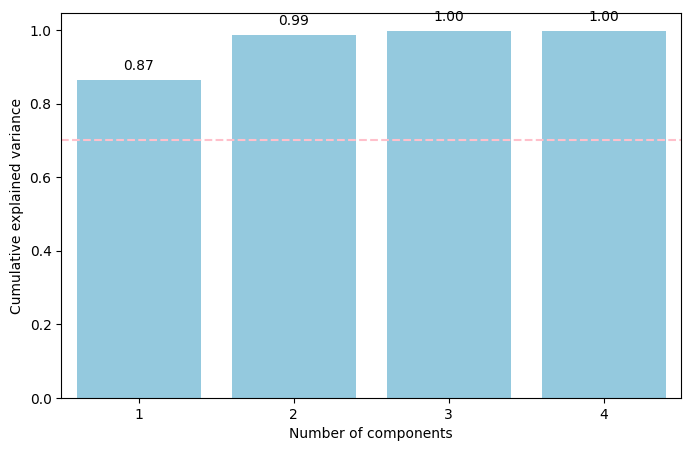

In [162]:
# Skumulowana zmienność
plt.figure(figsize=(8, 5))
sns.barplot(x=np.arange(1,5), y=np.cumsum(pca.explained_variance_ratio_)[:4], color='skyblue')
plt.axhline(y=0.7, color='pink', linestyle='--', label='70% Wariancji')
for i, v in enumerate(np.cumsum(pca.explained_variance_ratio_)[:4]):
    plt.text(i , v + 0.02, f"{v:.2f}", ha='center', va='bottom')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.show()

In [163]:
X_train_pca.shape

(6400, 4)

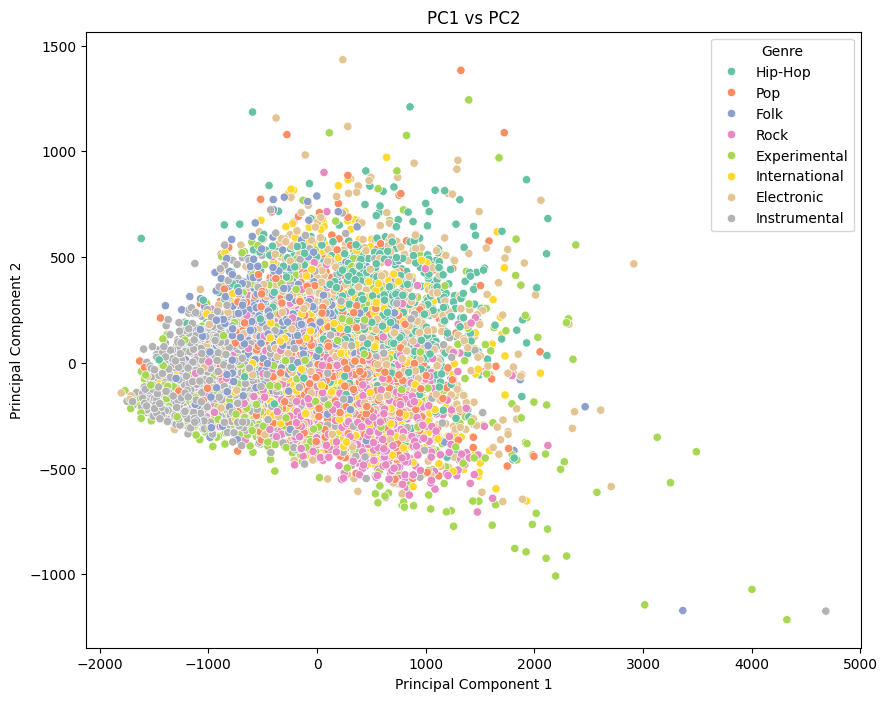

In [164]:
# PC1 vs PC2
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train, palette='Set2')
plt.title('PC1 vs PC2')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Genre')
plt.show()

## Wstępne modelowanie


In [39]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

In [165]:
scaler = StandardScaler()
X_train_pca = scaler.fit_transform(X_train_pca)
X_test_pca = scaler.transform(X_test_pca)

In [166]:
model_svm = SVC(kernel='linear', C=1, random_state=42)
model_svm.fit(X_train_pca, y_train)
y_pred_test_svm = model_svm.predict(X_test_pca)
y_pred_train_svm = model_svm.predict(X_train_pca)
print("SVM Train Accuracy: ", accuracy_score(y_train, y_pred_train_svm))
print("SVM Test Accuracy: ", accuracy_score(y_test, y_pred_test_svm))

SVM Train Accuracy:  0.34203125
SVM Test Accuracy:  0.33875


In [94]:
model_RF = RandomForestClassifier(n_estimators=500, max_depth=20, min_samples_leaf=2, random_state=42)
model_RF.fit(X_train_pca, y_train)
y_pred_test_RF = model_RF.predict(X_test_pca)
y_pred_train_RF = model_RF.predict(X_train_pca)
print("Random Forest Train Accuracy: ", accuracy_score(y_train, y_pred_train_RF))
print("Random Forest Test Accuracy: ", accuracy_score(y_test, y_pred_test_RF))

Random Forest Train Accuracy:  0.98203125
Random Forest Test Accuracy:  0.35625


## Modelowanie bez PCA

In [167]:
scaler = StandardScaler()
X_train_nopca = scaler.fit_transform(X_train)
X_test_nopca = scaler.transform(X_test)

In [168]:
X_train_nopca.shape

(6400, 70)

In [169]:
model_RF = RandomForestClassifier(n_estimators=500, max_depth=10, min_samples_leaf=5, random_state=42)
model_RF.fit(X_train_nopca, y_train)
y_pred_test_RF = model_RF.predict(X_test_nopca)
y_pred_train_RF = model_RF.predict(X_train_nopca)
print("Random Forest Train Accuracy: ", accuracy_score(y_train, y_pred_train_RF))
print("Random Forest Test Accuracy: ", accuracy_score(y_test, y_pred_test_RF))

Random Forest Train Accuracy:  0.8128125
Random Forest Test Accuracy:  0.456875


In [170]:
model_svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
model_svm.fit(X_train_nopca, y_train)
y_pred_test_svm = model_svm.predict(X_test_nopca)
y_pred_train_svm = model_svm.predict(X_train_nopca)
print("SVM Train Accuracy: ", accuracy_score(y_train, y_pred_train_svm))
print("SVM Test Accuracy: ", accuracy_score(y_test, y_pred_test_svm))

SVM Train Accuracy:  0.97734375
SVM Test Accuracy:  0.42875


In [112]:
from sklearn.ensemble import GradientBoostingClassifier
model_GB = GradientBoostingClassifier(
    n_estimators=100,      # Na początek 100 wystarczy, żeby sprawdzić trend
    learning_rate=0.01,     # Standardowy krok uczenia
    max_depth=4,           # BARDZO WAŻNE: Boosting używa płytkich drzew (tzw. stumps)
    subsample=0.8,         # Uczymy na 80% danych (dodaje element losowości, chroni przed overfittingiem)
    random_state=42,
)

model_GB.fit(X_train_nopca, y_train)

y_pred_train_GB = model_GB.predict(X_train_nopca)
y_pred_test_GB = model_GB.predict(X_test_nopca)

print(f"GB Train Accuracy: {accuracy_score(y_train, y_pred_train_GB):.4f}")
print(f"GB Test Accuracy: {accuracy_score(y_test, y_pred_test_GB):.4f}")

GB Train Accuracy: 0.5933
GB Test Accuracy: 0.4681
